# 📈 Redes Neuronales Recurrentes (RNN) y Series Temporales

## 1️⃣ ¿Qué son las Series Temporales?

Una **serie temporal** es un conjunto de observaciones ordenadas en el tiempo.

Ejemplos:
- Precio de acciones por día.
- Ventas mensuales.
- Temperatura por hora.
- Demanda eléctrica por minuto.

Formalmente:

$
y_t = f(t) + \varepsilon_t
$

Donde:
- $ y_t $ = valor en el tiempo \( t \)
- $ f(t) $ = tendencia o patrón
- $ \varepsilon_t $ = ruido aleatorio

---

## 2️⃣ Componentes de una Serie Temporal

Una serie temporal puede tener:

- 📈 **Tendencia (Trend)** → Crecimiento o decrecimiento a largo plazo.
- 🔁 **Estacionalidad (Seasonality)** → Patrones que se repiten.
- 🔄 **Ciclo (Cycle)** → Variaciones no periódicas.
- 🎲 **Ruido (Noise)** → Componente aleatorio.

---

## 3️⃣ Problema del Modelado Temporal

En Machine Learning tradicional:

$
y = f(x)
$

Pero en series temporales:

$
y_t = f(y_{t-1}, y_{t-2}, ..., y_{t-n})
$

Es decir:
> El pasado influye en el futuro.

Aquí es donde entran las **Redes Neuronales Recurrentes (RNN)**.

---

# 🔁 Redes Neuronales Recurrentes (RNN)

## 4️⃣ ¿Qué es una RNN?

Una **RNN (Recurrent Neural Network)** es una red neuronal diseñada para trabajar con datos secuenciales.

A diferencia de una red tradicional:

- Las redes feedforward NO recuerdan el pasado.
- Las RNN sí tienen memoria.

---


## 🔹 LSTM (Long Short-Term Memory)

Las LSTM introducen:

- Puerta de olvido (Forget Gate)
- Puerta de entrada (Input Gate)
- Puerta de salida (Output Gate)

Permiten:
- Recordar información relevante
- Olvidar información irrelevante

Son ideales para:
- Series financieras
- Lenguaje natural
- Señales médicas

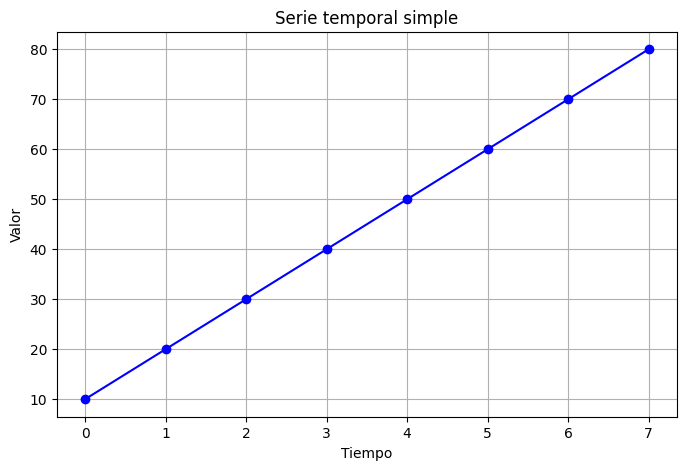

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Serie temporal
data = np.array([10, 20, 30, 40, 50, 60, 70, 80])
tiempo = np.arange(len(data))  # [0, 1, 2, ..., 7]

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(tiempo, data, marker='o', linestyle='-', color='blue')
plt.title('Serie temporal simple')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.xticks(tiempo)  # Para que los ticks coincidan con los índices
plt.show()

# CREAMOS SENCUENCIAS DE NÚMEROS

In [2]:
# Función para crear secuencias
def create_sequences(data, seq_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])  # Secuencia de entrada (X)
        y.append(data[i+seq_length])    # Valor a predecir (y)
    return np.array(X), np.array(y)

In [3]:
# Crear secuencias con longitud 3
seq_length = 3
X, y = create_sequences(data, seq_length)
# Mostrar los resultados
print("X (Secuencias de entrada):")
print(X)
print("\ny (Valores esperados):")
print(y)

X (Secuencias de entrada):
[[10 20 30]
 [20 30 40]
 [30 40 50]
 [40 50 60]
 [50 60 70]]

y (Valores esperados):
[40 50 60 70 80]


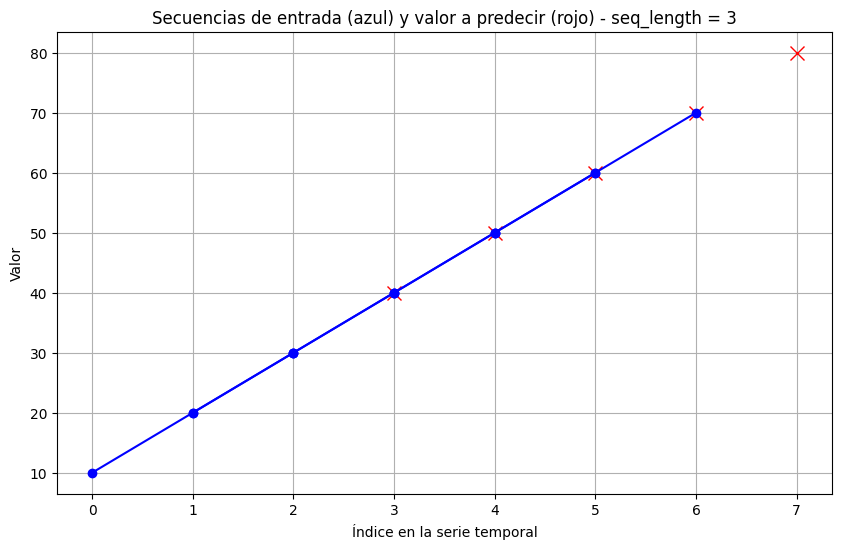

In [4]:
# Graficar cada secuencia y el valor real siguiente
plt.figure(figsize=(10, 6))
for i in range(len(X)):
    # Marcar la secuencia
    plt.plot(range(i, i + seq_length), X[i], marker='o', color='blue')
    # Marcar el valor objetivo (el siguiente después de la secuencia)
    plt.plot(i + seq_length, y[i], marker='x', color='red', markersize=10)

plt.title(f'Secuencias de entrada (azul) y valor a predecir (rojo) - seq_length = {seq_length}')
plt.xlabel('Índice en la serie temporal')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

In [5]:
# Redimensionar X para que tenga la forma adecuada para LSTM: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Agregar dimensión de características
X

array([[[10],
        [20],
        [30]],

       [[20],
        [30],
        [40]],

       [[30],
        [40],
        [50]],

       [[40],
        [50],
        [60]],

       [[50],
        [60],
        [70]]])

# CREA UNA RED NEURONAL LSTM

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## CREAMOS REDE NEURONAL RECURRENTE CON LSTM

In [7]:
model = Sequential([
    LSTM(100, activation='relu', input_shape=(seq_length, 1)),  # Capa LSTM con 100 neuronas
    Dense(1)  # Capa de salida con 1 neurona para predecir el siguiente valor
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [12]:
model = Sequential([
    LSTM(
        128,
        activation="tanh",
        recurrent_activation="sigmoid",
        return_sequences=True,
        input_shape=(seq_length, 1)
    ),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(
        64,
        activation="tanh",
        recurrent_activation="sigmoid",
        return_sequences=False
    ),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## CONFIGURAMOS LA RED NEURONAL

In [8]:
model.compile(optimizer='adam', loss='mse')

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 3, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,337 (462.25 KB)

 Non-trainable params: 256 (1.00 KB)

## ENTRENAMOS LA RED NEURONAL

In [17]:
model.fit(X, y, epochs=50, verbose=1)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 37.7420 - mae: 4.8870
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 26.8583 - mae: 4.2161
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 32.5059 - mae: 4.4619
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 30.9240 - mae: 4.5988
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 18.0061 - mae: 3.5726
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 72.2632 - mae: 7.3602
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 72.8255 - mae: 7.6151
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 34.7228 - mae: 4.8524
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 30.1118 - mae: 4.7647
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 26.7219 - mae: 4.6077
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 23.1957 - mae: 3.1835
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 23.3146 - mae: 4.7310
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

## # Hacer una predicción

In [18]:

last_sequence = np.array([60, 70, 80]).reshape((1, seq_length, 1))  # Últimos 3 valores como entrada
predicted_value = model.predict(last_sequence)
next_value = predicted_value[0][0]
print(f"\n🔮 Predicción del siguiente valor después de 80: {next_value:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

🔮 Predicción del siguiente valor después de 80: 77.09
